In [1]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np
import pandas as pd

In [2]:
from scipy.integrate import solve_ivp

In [3]:
import plotly.graph_objects as go

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [5]:
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    return data[indices]

In [6]:
def plot_debd_static(
        whole_series=None,
        perturbed_series=None,
        tau=1,
        name="",
        steps=[0,50,100,1000],
        freq = 10
):
    # compute embeddings
    X_de = delay_embedding(whole_series, d=3, tau=tau)
    des = np.array([delay_embedding(perturbed_series[i, :], d=3, tau=tau)
                    for i in range(100)])
    
    # the four time‐steps you want
    indices = np.array(steps)/freq 
    
    
    # create a single row of 4 subplots
    fig = plt.figure(figsize=(20, 5))
    for i, idx in enumerate(indices):
        idx = int(idx)
        ax = fig.add_subplot(1, len(indices), i+1, projection='3d')
        
        # plot the whole‐series trajectory
        ax.plot(
            X_de[:, 0],
            X_de[:, 1],
            X_de[:, 2],
            lw=0.05, color='blue', alpha=0.7,
            label='original'
        )
        # plot the perturbed points at step idx
        ax.scatter(
            des[:, idx, 0],
            des[:, idx, 1],
            des[:, idx, 2],
            s=2, color='red', alpha=0.7,
            label=f'perturbed'
        )
        
        ax.set_title(f"{name}\nstep {steps[i]}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])  # optional–clean up
        if i == 0:
            ax.legend(loc='upper left', fontsize='small')
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_debd(whole_series= None, perturbed_series=None, tau = 1,name=None):
    X_de = delay_embedding(whole_series, d=3, tau=tau)
    des = [delay_embedding(perturbed_series[i,:], d=3, tau=tau) for i in range(100)]
    des = np.array(des)
    for indx in [0,200,500,1000]:
        fig = go.Figure(data=[
            go.Scatter3d(
                x=X_de[:10000,0], 
                y=X_de[:10000,1], 
                z=X_de[:10000,2],
                mode='lines',
                line=dict(width=0.4, color='rgba(0,0,255,0.7)')
            ),
            go.Scatter3d(
                x=des[:,indx, 0],
                y=des[:,indx, 1],
                z=des[:,indx, 2],
                mode='markers',
                marker=dict(size=2, color='rgba(2550,0,0,0.7)', symbol='circle')
            )
        ])

        fig.update_layout(title=name+f"at step {indx}")
        fig.show()

In [8]:
def MG_generate2(gamma=1,beta=2,tau=2,theta=1,n=11,length = 10000,delta=0.01,x_past = None):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4_interp(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6
  N = int(np.floor(length/delta))
  x_past = np.array(x_past)
  if x_past[-1] == 0:
    x = x_past[-1]+0.1
  else:
    x = x_past[-1]
  past_len = int(np.floor(tau/delta))
  if past_len != len(x_past):
    raise ValueError("past length and x_past length do not match")
  x_past = np.concatenate((x_past, np.zeros(N+1)))
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    x_delta = MG_rk4_interp(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta
  return T,X

In [9]:
import numpy as np
def MG_generate(gamma=1,beta=2,tau=60,theta=1,n=10,x0=1,N=2000000,delta=0.001, interp = True):
  def MG_eq (x,x_pre):
    return x_pre * beta * (theta**n)/(theta**n+x_pre**n)-gamma*x

  def MG_rk4_interp(x,x_pre,x_pre_f):
    interplot = (x_pre+x_pre_f)/2
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,interplot)
    k3 = MG_eq(x+delta*k2/2,interplot)
    k4 = MG_eq(x+delta*k3,x_pre_f)
    return x+delta*(k1+2*k2+2*k3+k4)/6
  
  def MG_rk4(x,x_pre):
    k1 = MG_eq(x,x_pre)
    k2 = MG_eq(x+delta*k1/2,x_pre)
    k3 = MG_eq(x+delta*k2/2,x_pre)
    k4 = MG_eq(x+delta*k3,x_pre)
    return x+delta*(k1+2*k2+2*k3+k4)/6

  past_len = int(np.floor(tau/delta))
  x_past = np.zeros(past_len+N+1)+1.2
  x_past[past_len-1] = x0
  x = x0
  X = np.zeros(N+1)
  T = np.zeros(N+1)
  time = 0

  for i in range(N+1):
    X[i] = x
    x_pre = x_past[i]
    x_pre_f = x_past[i+1]
    if interp:
      x_delta = MG_rk4_interp(x=x,x_pre=x_pre,x_pre_f = x_pre_f)
    else:
      x_delta = MG_rk4(x=x,x_pre=x_pre)
    x_past[i+past_len] = x_delta
    T[i] = time
    time += delta
    x = x_delta

  interval = int(np.floor(1/delta))
  T,X = T[::interval],X[::interval]
  return T,X

# Mackey-Glass

In [ ]:
_,X = MG_generate(tau = 2, n = , N = 10000000,delta = 0.01,x0 = 1)

In [13]:
data = {'9_5':np.array(X)}
df = pd.DataFrame(data)
df.to_parquet('MG_n_9_5_whole.parquet')

In [190]:
data = {'11':np.array(X)}
df = pd.DataFrame(data)
df.to_parquet('MG_n_11_whole.parquet')

In [193]:
_,X = MG_generate(tau = 2, n = 9, N = 10000000,delta = 0.01,x0 = 1)

In [194]:
data = {'9':np.array(X)}
df = pd.DataFrame(data)
df.to_parquet('MG_n_9.parquet')

In [42]:
data = {}
for i in range(10):
    _,X = MG_generate(tau = 2, n = 11, N = 1000000,delta = 0.01,x0 = i+1)
    data[f"{i+1}"] = np.array(X)

In [43]:
df = pd.DataFrame(data)
df.to_parquet('MG_n_11_separate_x0.parquet')

# Lorentz

In [46]:
# Define the Lorenz system of differential equations
def lorenz(t, y, sigma, rho, beta):
    dydt = [sigma * (y[1] - y[0]),
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return dydt

# Set the parameters
sigma = 10.0
rho = 28.0
beta = 3

# Set the initial conditions
initial_conditions = [1.0, 0.0, 20.0]

# Set the time span for integration
t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 100000)

# Solve the system of differential equations
sol = solve_ivp(lorenz, 
                t_span, 
                initial_conditions, 
                args=(sigma, rho, beta), 
                t_eval=t_eval
            )

# Extract the solution
y_l = sol.y
t = sol.t

In [30]:
X_de = delay_embedding(y_l[0], d=3, tau=10)

In [31]:
X = []
for i in range(100):
    t_span = (0, 1000)
    t_eval = np.linspace(t_span[0], t_span[1], 100000)
    # Solve the system of differential equations
    sol = solve_ivp(lorenz, 
                    t_span, 
                    initial_conditions+i*np.array([0.01, 0.01, 0.01]),
                    args=(sigma, rho, beta), 
                    t_eval=t_eval
                )

    # Extract the solution
    x = sol.y[0]
    X.append(x)
X = np.array(X)

In [32]:
des = [delay_embedding(X[i], d=3, tau=10) for i in range(100)]
des = np.array(des)

In [34]:
des.shape

(100, 99980, 3)

In [36]:
indx=1000
fig = go.Figure(data=[
    go.Scatter3d(
        x=X_de[:,0], 
        y=X_de[:,1], 
        z=X_de[:,2],
        mode='lines',
        line=dict(width=0.5, color='rgba(0,0,256,0.7)')
    ),
    go.Scatter3d(
        x=des[:,indx, 0],
        y=des[:,indx, 1],
        z=des[:,indx, 2],
        mode='markers',
        marker=dict(size=1, color='rgba(0,255,0,0.7)', symbol='circle')
    )
])

fig.update_layout(title='delay embedding if sensitive to perturbation')
fig.show()

In [47]:
fig = go.Figure(data=[go.Scatter3d(
    x=y_l[0], y=y_l[1], z=y_l[2],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz Attractor')
fig.show()

In [48]:
data = {'x': y_l[0], 'y': y_l[1], 'z': y_l[2]}
df = pd.DataFrame(data)
df.to_parquet('lrz_sig_10_rho_28_beta_3_whole.parquet')

In [49]:
data = {}
for i in range(10):
    t_span = (0, 100)
    t_eval = np.linspace(t_span[0], t_span[1], 10000)
    # Solve the system of differential equations
    sol = solve_ivp(lorenz, 
                    t_span, 
                    initial_conditions+i*np.array([1, 1, 1]),
                    args=(sigma, rho, beta), 
                    t_eval=t_eval
                )

    # Extract the solution
    y_l = sol.y
    t = sol.t
    data[f"{i}_x"] = y_l[0]
    data[f"{i}_y"] = y_l[1]
    data[f"{i}_z"] = y_l[2]

df = pd.DataFrame(data)
df.to_parquet('lrz_sig_10_rho_28_beta_3_separate_x0.parquet')



In [50]:
i = 9
fig = go.Figure(data=[go.Scatter3d(
    x=df[f"{i}_x"], y = df[f"{i}_y"], z = df[f"{i}_z"],
    mode='lines',
    line=dict(width=2, color='rgba(0,0,255,0.3)')
)])
fig.update_layout(title='Lorenz Attractor')
fig.show()

# Logistic Map

In [7]:
def lgm(x0=0,r = 4,N =100000):
    X = []
    x = x0
    for i in range(N):
        X.append(x)
        x = r * x * (1 - x)

    return np.array(X)

In [42]:
X = lgm(x0=0.1, r=3.81, N=100000)

In [43]:
X_de = delay_embedding(X, d=3, tau=1)


In [ ]:
X = []
for i in range(100):
    x = lgm(x0=i/10, r=3.81, N=100000)
    X.append(x)

X = np.array(X)

In [45]:
X = np.array(X)

In [46]:
des = [delay_embedding(s, d=3, tau=1) for s in X]


In [47]:
des = np.array(des)

In [48]:
indx=70000
fig = go.Figure(data=[
    go.Scatter3d(
        x=X_de[:,0][:1000], 
        y=X_de[:,1][:1000], 
        z=X_de[:,2][:1000],
        mode='lines',
        line=dict(width=0.5, color='rgba(0,0,256,0.7)')
    ),
    go.Scatter3d(
        x=des[:,indx, 0],
        y=des[:,indx, 1],
        z=des[:,indx, 2],
        mode='markers',
        marker=dict(size=1, color='rgba(0,255,0,0.7)', symbol='circle')
    )
])

fig.update_layout(title='delay embedding if sensitive to perturbation')
fig.show()

In [68]:
fig = go.Figure(data=[
    go.Scatter3d(
        x=X_de[:,0][:1000], 
        y=X_de[:,1][:1000],
        z=X_de[:,2][:1000],
        mode='lines',
        line=dict(width=1, color='rgba(0,0,256,0.7)')
    )
])


fig.update_layout(title='delay embedding ')
fig.show()

# Perturbed MG

In [ ]:
x_past = np.zeros(300)+1.2
x_past[-1] = 1

In [ ]:
_,X = MG_generate2(length = 90000,x_past = x_past,n= 9,delta = 0.01,tau=3)
x_past = X[-300:]
results = []
for i in range(100):
    new_past = x_past[-300:].copy()
    new_past[-1] = new_past[-1]-0.02+0.0004*i
    #print(new_past[-1])
    _,x = MG_generate2(length = 2000,x_past = new_past,n= 9,tau=3)
    x = np.concatenate((np.array(new_past[:-1]),np.array(x)))
    results.append(x)

results= np.stack(results)

ValueError: past length and x_past length do not match

In [27]:
results = results[:,99::100]

In [24]:
results.shape

(100, 2002)

In [142]:
df = pd.DataFrame(results)
df.to_parquet('MG_true_pert.parquet')

In [17]:
df = pd.read_parquet('MG_n_9.parquet')

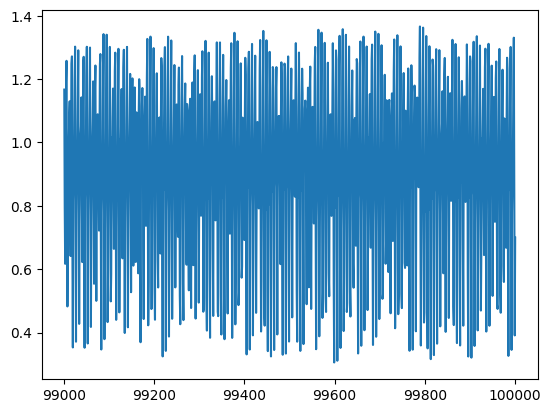

In [192]:
plt.plot(df["11"][-1000:])

In [157]:
df.iloc[90001]

11    0.874413
Name: 90001, dtype: float64

In [19]:
df

,9
0,1.000000
1,0.614169
2,0.481160
3,1.006055
4,1.024330
...,...
99996,1.089997
99997,1.115538
99998,1.075712
99999,0.784698


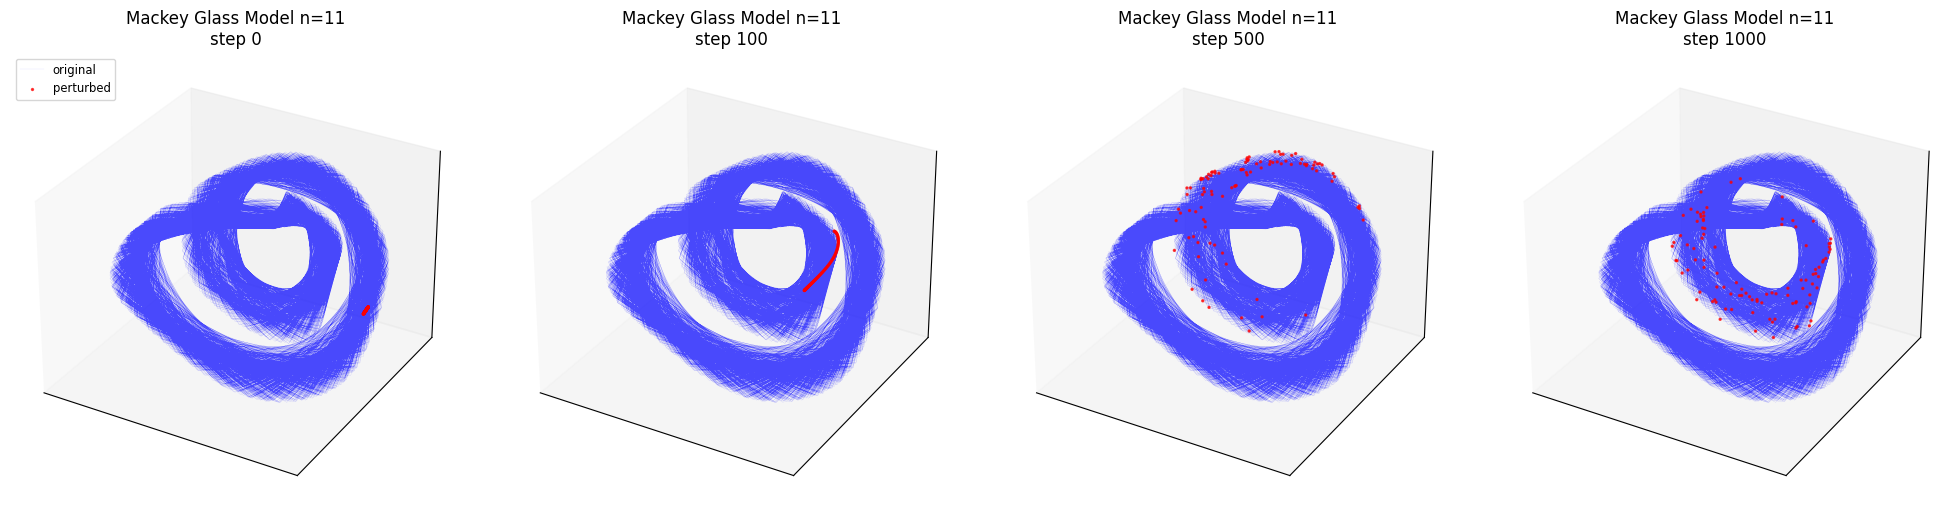

In [30]:
plot_debd_static(whole_series=np.array(df).squeeze()[-10000:], 
                 perturbed_series=results, tau=1, 
                 name='Mackey Glass Model n=11', 
                 steps=[0, 100, 500, 1000], freq=1)

# Perturbed Lorenz

In [144]:
# Define the Lorenz system of differential equations
def lorenz(t, y, sigma, rho, beta):
    dydt = [sigma * (y[1] - y[0]),
            y[0] * (rho - y[2]) - y[1],
            y[0] * y[1] - beta * y[2]]
    return dydt

# Set the parameters
sigma = 10.0
rho = 28.0
beta = 3

# Set the initial conditions
initial_conditions = [1.0, 0.0, 20.0]

# Set the time span for integration
t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 100001)

# Solve the system of differential equations
sol = solve_ivp(lorenz, 
                t_span, 
                initial_conditions, 
                args=(sigma, rho, beta), 
                t_eval=t_eval
            )

# Extract the solution
y_l = sol.y
t = sol.t

In [145]:
X = []
initial_conditions = y_l[:,90001].copy()
for i in range(100):
    t_span = (0, 20)
    t_eval = np.linspace(t_span[0], t_span[1], 2001)
    # Solve the system of differential equations
    sol = solve_ivp(lorenz, 
                    t_span, 
                    initial_conditions-0.2*np.array([1,1,1])+i*np.array([0.004, 0, 0]),
                    args=(sigma, rho, beta), 
                    t_eval=t_eval
                )

    # Extract the solution
    x = sol.y[0]
    x = np.insert(x, 0, y_l[0,90000])  # insert the initial condition
    X.append(x)
X = np.stack(X)

In [146]:
X.shape

(100, 2002)

In [147]:
df = pd.DataFrame(X)
df.to_parquet('lrz_true_pert.parquet')

In [148]:
df = pd.read_parquet("lrz_sig_10_rho_28_beta_3_whole.parquet")

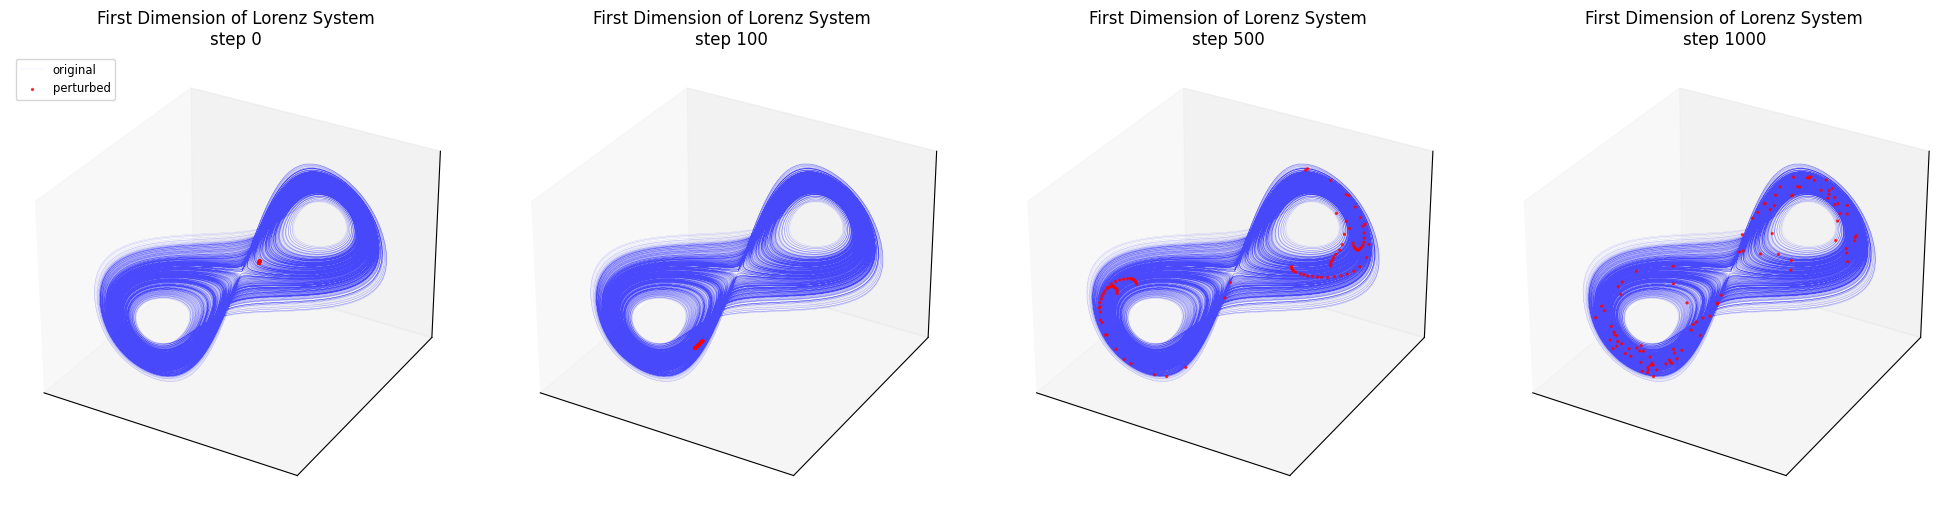

In [120]:
plot_debd_static(whole_series=np.array(df.iloc[:,0]).squeeze()[:], 
                 perturbed_series=X, tau=10, 
                 name='First Dimension of Lorenz System', 
                 steps=[0, 100, 500, 1000], freq=1)